## Introduction

**Target Audience:** MLB front office analysts and general managers evaluating pitcher contracts and player salaries.

**Motivation:** MLB pitcher salaries vary enormously from league-minimum contracts to deals exceeding $50M/year — yet performance statistics suggest that salary does not always reflect on-field value. This analysis investigates the relationship between pitching performance metrics and salary across the 2021–2025 seasons (the five most recent complete seasons), with the goal of identifying which pitchers are overpaid or underpaid relative to their statistical output and recommending specific trade or contract targets for the upcoming offseason.

**Key Questions:**
1. Which performance metrics best predict ERA?
2. Which metrics best predict salary?
3. Which pitchers are most over-or underpaid relative to their statistical profile, and which 2025 underpaid pitchers represent the best value targets going forward?

## 1. Setup & Imports

In [1]:
# pip install requests pandas pybaseball scikit-learn seaborn matplotlib

import requests
import pandas as pd
from io import StringIO
import time
import os
import sqlite3
import logging
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
DB_PATH = "pitcher_stats.db"
YEARS = [2021, 2022, 2023, 2024, 2025]

SAVANT_URL = "https://baseballsavant.mlb.com"
MLB_URL = "https://statsapi.mlb.com/api/v1"
HEADERS = {"User-Agent": "Mozilla/5.0"}

PITCH_TYPES = ["FF", "SI", "FC", "SL", "CU", "CH", "FS", "ST", "SV"]


In [4]:
logging.basicConfig(level=logging.INFO)
log = logging.getLogger(__name__)

conn = sqlite3.connect(DB_PATH)

## 2. Data Collection

Three sources are pulled and stored in a local SQLite database:
- **MLB Stats API** standard pitching stats per season
- **Baseball Savant** Statcast expected stats, pitch arsenal, and movement
- **FanGraphs (pybaseball)** salary data mapped to MLBAM player IDs

In [5]:
def get_mlb_pitching_stats(season):
    url = f"{MLB_URL}/stats"
    params = {
        "stats": "season",
        "group": "pitching",
        "season": season,
        "gameType": "R",
        "limit": 2000
    }
    r = requests.get(url, params=params)
    data = r.json()
    rows = []
    for split in data["stats"][0]["splits"]:
        stat = split["stat"]
        player = split["player"]
        team = split["team"]
        rows.append({
            "player_id": player["id"],
            "name": player["fullName"],
            "team": team["name"],
            "season": season,
            "age": player.get("currentAge"),
            "G": stat.get("gamesPitched"),
            "GS": stat.get("gamesStarted"),
            "IP": stat.get("inningsPitched"),
            "H": stat.get("hits"),
            "R": stat.get("runs"),
            "ER": stat.get("earnedRuns"),
            "BB": stat.get("baseOnBalls"),
            "SO": stat.get("strikeOuts"),
            "ERA": stat.get("era"),
            "groundOuts": stat.get("groundOuts"),
            "airOuts": stat.get("airOuts"),
        })
    return pd.DataFrame(rows)


In [6]:
def _savant_get(url, params):
    """Shared helper with error handling for Savant CSV endpoints."""
    try:
        r = requests.get(url, params=params, headers=HEADERS, timeout=15)
        r.raise_for_status()
        return pd.read_csv(StringIO(r.text))
    except requests.RequestException as e:
        log.warning(f"Savant request failed ({url}): {e}")
        return pd.DataFrame()
    except Exception as e:
        log.warning(f"Failed to parse Savant CSV ({url}): {e}")
        return pd.DataFrame()

In [7]:
def get_pitch_arsenal(season):
    return _savant_get(f"{SAVANT_URL}/leaderboard/pitch-arsenal-stats",
                       {"type": "pitcher", "year": season, "minPA": 1, "csv": "true"})

def get_pitch_movement(season):
    return _savant_get(f"{SAVANT_URL}/leaderboard/pitch-movement",
                       {"year": season, "min": 1, "csv": "true"})

def get_expected_stats(season):
    return _savant_get(f"{SAVANT_URL}/leaderboard/expected_statistics",
                       {"type": "pitcher", "year": season, "min": 1, "csv": "true"})

def get_statcast_stats(season):
    return _savant_get(f"{SAVANT_URL}/leaderboard/statcast",
                       {"type": "pitcher", "year": season, "min": 1, "csv": "true"})

In [8]:
def pivot_arsenal(df):
    if df.empty:
        return pd.DataFrame()
    df = df[df['pitch_type'].isin(PITCH_TYPES)].copy()
    pivot = df.pivot_table(index='player_id', columns='pitch_type',
                           values='pitch_usage', aggfunc='first').reset_index()
    pivot.columns = ['player_id'] + [f'{c}_pct' for c in pivot.columns[1:]]
    return pivot


def pivot_movement(df):
    if df.empty:
        return pd.DataFrame()
    df = df[df['pitch_type'].isin(PITCH_TYPES)].copy()
    id_col = 'pitcher_id' if 'pitcher_id' in df.columns else 'player_id'

    velo = df.pivot_table(index=id_col, columns='pitch_type',
                          values='avg_speed', aggfunc='first').reset_index()
    velo.columns = ['player_id'] + [f'{c}_velo' for c in velo.columns[1:]]

    ivb = df.pivot_table(index=id_col, columns='pitch_type',
                         values='pitcher_break_z_induced', aggfunc='first').reset_index()
    ivb.columns = ['player_id'] + [f'{c}_ivb' for c in ivb.columns[1:]]
    return velo.merge(ivb, on='player_id', how='outer')

In [9]:
def build_dataset(years):
    all_data = []
    for year in years:
        log.info(f"Pulling {year}")

        mlb_stats = get_mlb_pitching_stats(year)
        time.sleep(0.5)
        arsenal = get_pitch_arsenal(year)
        time.sleep(1)
        movement = get_pitch_movement(year)
        time.sleep(1)
        expected = get_expected_stats(year)
        time.sleep(1)
        statcast = get_statcast_stats(year)
        time.sleep(1)

        merged = mlb_stats.copy()

        if "groundOuts" in merged.columns and "airOuts" in merged.columns:
            merged["groundOuts"] = pd.to_numeric(merged["groundOuts"], errors="coerce")
            merged["airOuts"] = pd.to_numeric(merged["airOuts"], errors="coerce")
            total = merged["groundOuts"] + merged["airOuts"]
            merged["GB_pct"] = (merged["groundOuts"] / total * 100).round(1)
            merged["FB_pct"] = (merged["airOuts"] / total * 100).round(1)
        else:
            merged["GB_pct"] = float("nan")
            merged["FB_pct"] = float("nan")

        if not expected.empty:
            keep = ["player_id"] + [c for c in ["xera", "est_woba"] if c in expected.columns]
            if len(keep) > 1:
                merged = merged.merge(
                    expected[keep].rename(columns={"xera": "xERA", "est_woba": "xwOBA"}),
                    on="player_id", how="left")

        if not statcast.empty:
            ev_col = "avg_hit_speed" if "avg_hit_speed" in statcast.columns else None
            if ev_col:
                merged = merged.merge(
                    statcast[["player_id", ev_col]].rename(columns={ev_col: "EV"}),
                    on="player_id", how="left")

        ap = pivot_arsenal(arsenal)
        mp = pivot_movement(movement)
        if not ap.empty:
            merged = merged.merge(ap, on="player_id", how="left")
        if not mp.empty:
            merged = merged.merge(mp, on="player_id", how="left")

        all_data.append(merged)
        log.info(f"  {year}: {len(merged)} pitchers, {len(merged.columns)} cols")

    final_df = pd.concat(all_data, ignore_index=True)
    drop = [c for c in ["groundOuts", "airOuts", "total_outs"] if c in final_df.columns]
    return final_df.drop(columns=drop)


In [10]:
def load_to_sqlite(df, table_name="pitcher_stats"):
    log.info(f"Writing {len(df):,} rows to '{table_name}'...")
    df.to_sql(table_name, conn, if_exists="replace", index=False)
    count = pd.read_sql(f"SELECT COUNT(*) AS n FROM {table_name}", conn).iloc[0]["n"]
    log.info(f"  ✅ {count:,} rows loaded into '{table_name}'\n")

In [11]:
def build_salary_table(years):
    """Pull salary data from FanGraphs via pybaseball and map to MLBAM IDs."""
    from pybaseball import pitching_stats, playerid_reverse_lookup
    import re

    log.info("Pulling FanGraphs salary data")
    frames = []
    for year in years:
        df = pitching_stats(year, year, qual=0)
        df['season'] = year
        frames.append(df)
        log.info(f"  {year}: {len(df)} pitchers")

    all_salaries = pd.concat(frames, ignore_index=True)

    # Map FanGraphs IDs → MLBAM IDs
    log.info("  Looking up MLBAM IDs...")
    fg_ids = all_salaries['IDfg'].dropna().astype(int).unique().tolist()
    id_map = playerid_reverse_lookup(fg_ids, key_type='fangraphs')
    id_map['key_fangraphs'] = id_map['key_fangraphs'].astype(int)
    all_salaries['IDfg'] = all_salaries['IDfg'].astype(int)

    salary_with_ids = all_salaries.merge(
        id_map[['key_fangraphs', 'key_mlbam']],
        left_on='IDfg', right_on='key_fangraphs', how='left'
    )

    # Clean Dollars column — handles $59.8 and (0.3) negative notation
    def clean_salary(val):
        if pd.isna(val):
            return None
        val = str(val).strip()
        negative = '(' in val
        val = re.sub(r'[$(),]', '', val)
        try:
            result = float(val) * 1_000_000
            return -result if negative else result
        except Exception:
            return None

    salary_with_ids['salary'] = salary_with_ids['Dollars'].apply(clean_salary)

    fg_salaries = (salary_with_ids[['key_mlbam', 'season', 'salary']]
                   .rename(columns={'key_mlbam': 'player_id'})
                   .dropna(subset=['player_id', 'salary']))
    fg_salaries['player_id'] = fg_salaries['player_id'].astype(int)

    fg_salaries.to_sql("fg_salaries", conn, if_exists="replace", index=False)
    log.info(f"  ✅ fg_salaries: {len(fg_salaries):,} rows loaded\n")

In [12]:
def build_joined_table():
    """Join pitcher_stats with fg_salaries to create final analysis table."""
    log.info("Building pitcher_stats_with_salary")
    conn.execute("DROP TABLE IF EXISTS pitcher_stats_with_salary")
    conn.execute("""
        CREATE TABLE pitcher_stats_with_salary AS
        SELECT ps.*, fs.salary
        FROM pitcher_stats ps
        LEFT JOIN fg_salaries fs
            ON  ps.player_id = fs.player_id
            AND ps.season    = fs.season
    """)
    conn.commit()

    total   = pd.read_sql("SELECT COUNT(*) AS n FROM pitcher_stats_with_salary", conn).iloc[0]["n"]
    matched = pd.read_sql("SELECT COUNT(*) AS n FROM pitcher_stats_with_salary WHERE salary IS NOT NULL", conn).iloc[0]["n"]
    log.info(f"  ✅ {total:,} total rows | {matched:,} with salary ({matched/total*100:.1f}%)\n")

In [13]:
# RUN — Part 1: Pull Statcast + MLB Stats data

if __name__ == "__main__":
    log.info("═" * 50)
    log.info("PART 1 — Building Statcast / MLB Stats dataset")
    log.info("═" * 50)
    final_df = build_dataset(YEARS)
    log.info(f"Dataset complete: {final_df.shape[0]:,} rows x {final_df.shape[1]} columns")
    load_to_sqlite(final_df)

INFO:__main__:══════════════════════════════════════════════════
INFO:__main__:PART 1 — Building Statcast / MLB Stats dataset
INFO:__main__:══════════════════════════════════════════════════
INFO:__main__:Pulling 2021
INFO:__main__:  2021: 39 pitchers, 32 cols
INFO:__main__:Pulling 2022
INFO:__main__:  2022: 45 pitchers, 32 cols
INFO:__main__:Pulling 2023
INFO:__main__:  2023: 44 pitchers, 32 cols
INFO:__main__:Pulling 2024
INFO:__main__:  2024: 58 pitchers, 32 cols
INFO:__main__:Pulling 2025
INFO:__main__:  2025: 52 pitchers, 32 cols
INFO:__main__:Dataset complete: 238 rows x 30 columns
INFO:__main__:Writing 238 rows to 'pitcher_stats'...
INFO:__main__:  ✅ 238 rows loaded into 'pitcher_stats'



In [14]:
# RUN — Part 2: Pull FanGraphs salary data

if __name__ == "__main__":
    log.info("═" * 50)
    log.info("PART 2 — Pulling FanGraphs salary data")
    log.info("═" * 50)
    build_salary_table(YEARS)

INFO:__main__:══════════════════════════════════════════════════
INFO:__main__:PART 2 — Pulling FanGraphs salary data
INFO:__main__:══════════════════════════════════════════════════
INFO:__main__:Pulling FanGraphs salary data
INFO:__main__:  2021: 909 pitchers
INFO:__main__:  2022: 871 pitchers
INFO:__main__:  2023: 863 pitchers
INFO:__main__:  2024: 855 pitchers
INFO:__main__:  2025: 873 pitchers
INFO:__main__:  Looking up MLBAM IDs...


Gathering player lookup table. This may take a moment.


INFO:__main__:  ✅ fg_salaries: 4,003 rows loaded



In [15]:
# RUN — Part 3: Build final joined table

if __name__ == "__main__":
    log.info("═" * 50)
    log.info("PART 3 — Building final joined table")
    log.info("═" * 50)
    build_joined_table()

INFO:__main__:══════════════════════════════════════════════════
INFO:__main__:PART 3 — Building final joined table
INFO:__main__:══════════════════════════════════════════════════
INFO:__main__:Building pitcher_stats_with_salary
INFO:__main__:  ✅ 238 total rows | 235 with salary (98.7%)



In [16]:
def preview():
    """Quick look at top 20 highest-paid starters with 100+ IP."""
    log.info("Top 20 highest-paid starters with 100+ IP")
    df = pd.read_sql("""
        SELECT
            name, season, team,
            ROUND(IP, 1)                  AS IP,
            ERA, xERA, SO,
            ROUND(salary / 1000000.0, 2)  AS salary_millions
        FROM pitcher_stats_with_salary
        WHERE salary IS NOT NULL
          AND IP > 100
        ORDER BY season DESC, salary DESC
        LIMIT 20
    """, conn)

    if df.empty:
        log.warning("  No preview rows returned — check that salary data loaded correctly.")
    else:
        print(df.to_string(index=False))


In [17]:
# RUN — Part 4: Preview + wrap up

if __name__ == "__main__":
    log.info("═" * 50)
    log.info("PART 4 — Preview")
    log.info("═" * 50)
    preview()

    conn.close()
    print(f"\n✅ All done! Database saved to: {os.path.abspath(DB_PATH)}")
    print("Tables available:")
    print("  • pitcher_stats              — Statcast + MLB Stats data")
    print("  • fg_salaries                — FanGraphs salary data")
    print("  • pitcher_stats_with_salary  — Final joined table (use this one)")

INFO:__main__:══════════════════════════════════════════════════
INFO:__main__:PART 4 — Preview
INFO:__main__:══════════════════════════════════════════════════
INFO:__main__:Top 20 highest-paid starters with 100+ IP


              name  season                  team    IP  ERA  xERA  SO  salary_millions
      Tarik Skubal    2025        Detroit Tigers 195.1 2.21  2.71 241             53.1
Cristopher Sánchez    2025 Philadelphia Phillies 202.0 2.50  3.02 212             51.2
   Garrett Crochet    2025        Boston Red Sox 205.1 2.59  2.89 255             46.2
        Logan Webb    2025  San Francisco Giants 207.0 3.22  3.58 224             44.2
     Jesús Luzardo    2025 Philadelphia Phillies 183.2 3.92  3.33 216             42.7
Yoshinobu Yamamoto    2025   Los Angeles Dodgers 173.2 2.49  2.74 201             40.0
         Max Fried    2025      New York Yankees 195.1 2.86  3.38 189             38.2
      Hunter Brown    2025        Houston Astros 185.1 2.43  3.14 206             36.6
     Kevin Gausman    2025     Toronto Blue Jays 193.0 3.59  3.74 189             32.8
    Framber Valdez    2025        Houston Astros 192.0 3.66  3.79 187             32.1
     Andrew Abbott    2025       Cincinnati

## 3. Data Quality Checks

Before any analysis, we verify completeness, identify missing values, check for duplicates, and confirm that key numeric fields fall within reasonable ranges.

In [18]:
conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql("""
    SELECT name FROM sqlite_master WHERE type='table' ORDER BY name
""", conn)

print("Tables in database:")
rows = []
for t in tables['name']:
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t}", conn).iloc[0]["n"]
    rows.append({"table": t, "row_count": n})
print(pd.DataFrame(rows).to_string(index=False))

Tables in database:
                    table  row_count
              fg_salaries       4003
            pitcher_stats        238
pitcher_stats_with_salary        238
    pitcher_surplus_value        225


In [19]:
df_main = pd.read_sql("SELECT * FROM pitcher_stats_with_salary", conn)

null_pct = (df_main.isnull().sum() / len(df_main) * 100).round(1)
missing = pd.DataFrame({"missing_pct": null_pct})
missing = missing[missing["missing_pct"] > 0].sort_values("missing_pct", ascending=False)
print(f"Total rows: {len(df_main):,}")
print("\nColumns with missing values:")
print(missing.to_string())


Total rows: 238

Columns with missing values:
         missing_pct
age            100.0
SV_pct          96.6
FS_pct          92.0
ST_pct          80.7
FC_pct          71.4
SL_pct          64.3
CU_pct          63.9
CH_pct          61.3
SI_pct          49.2
FF_pct          18.9
FF_velo          1.7
FF_ivb           1.7
salary           1.3


In [20]:
df_main["ERA_num"] = pd.to_numeric(df_main["ERA"], errors="coerce")

checks = {
    "ERA":    df_main["ERA_num"],
    "IP":     df_main["IP"],
    "SO":     df_main["SO"],
    "BB":     df_main["BB"],
    "salary": df_main["salary"] / 1_000_000
}
range_df = pd.DataFrame({
    col: s.dropna().describe(percentiles=[.25, .5, .75, .95])
    for col, s in checks.items()
}).round(2)
print("Key column distribution:")
print(range_df)

Key column distribution:
           ERA     IP      SO      BB  salary
25%       3.09    NaN  150.00   42.00   16.80
50%       3.60    NaN  175.00   50.00   25.30
75%       4.22    NaN  201.00   59.75   32.95
95%       5.20    NaN  234.15   73.00   45.92
count   238.00    238  238.00  238.00  235.00
freq       NaN      7     NaN     NaN     NaN
max       6.28    NaN  281.00   99.00   59.80
mean      3.67    NaN  176.05   51.10   25.58
min       1.75    NaN   95.00   19.00   -3.10
std       0.82    NaN   34.88   13.05   11.84
top        NaN  192.0     NaN     NaN     NaN
unique     NaN    109     NaN     NaN     NaN


In [21]:
dupes = pd.read_sql("""
    SELECT player_id, season, COUNT(*) AS n
    FROM pitcher_stats_with_salary
    GROUP BY player_id, season HAVING n > 1
    LIMIT 10
""", conn)
print(f"Duplicate player/season rows: {len(dupes)}")
if len(dupes): print(dupes)

Duplicate player/season rows: 0


In [22]:
season_summary = pd.read_sql("""
    SELECT
        season,
        COUNT(*) AS total_pitchers,
        SUM(CASE WHEN salary IS NOT NULL THEN 1 ELSE 0 END) AS with_salary,
        ROUND(AVG(CAST(ERA AS FLOAT)), 2) AS avg_ERA,
        ROUND(AVG(IP), 1) AS avg_IP,
        ROUND(AVG(salary)/1000000.0, 1) AS avg_salary_M
    FROM pitcher_stats_with_salary
    WHERE ERA IS NOT NULL AND CAST(ERA AS FLOAT) < 20
    GROUP BY season ORDER BY season
""", conn)
print("Season summary:")
print(season_summary.to_string(index=False))

Season summary:
 season  total_pitchers  with_salary  avg_ERA  avg_IP  avg_salary_M
   2021              39           39     3.63   180.2          29.1
   2022              45           45     3.34   184.1          26.7
   2023              44           44     3.83   183.4          26.1
   2024              58           58     3.71   177.9          23.3
   2025              52           49     3.81   177.2          24.0


In [23]:
# SQL WINDOW FUNCTION: Rank pitchers by ERA within each season
# RANK() partitioned by season and ordered by ERA ascending (lower = better)
# Filtered to starters with 100+ IP for a meaningful comparison
# Shows who was the best pitcher each year and whether top-ranked pitchers

era_rankings = pd.read_sql("""
    SELECT
        name, season, team,
        ROUND(CAST(ERA AS FLOAT), 2) AS ERA,
        ROUND(IP, 1) AS IP,
        SO,
        ROUND(salary / 1000000.0, 2) AS salary_M,
        RANK() OVER (PARTITION BY season ORDER BY CAST(ERA AS FLOAT) ASC) AS era_rank
    FROM pitcher_stats_with_salary
    WHERE salary IS NOT NULL
      AND IP >= 100
      AND ERA IS NOT NULL
      AND CAST(ERA AS FLOAT) < 20
    ORDER BY season, era_rank
""", conn)

print("Top ERA pitchers per season (starters with 100+ IP):")
# Show top 5 per season
era_rankings[era_rankings['era_rank'] <= 5]

Top ERA pitchers per season (starters with 100+ IP):


,name,season,team,ERA,IP,SO,salary_M,era_rank
0,Corbin Burnes,2021,Milwaukee Brewers,2.43,167.0,234,59.8,1
1,Max Scherzer,2021,Los Angeles Dodgers,2.46,179.1,236,43.0,2
2,Walker Buehler,2021,Los Angeles Dodgers,2.47,207.2,212,44.4,3
3,Brandon Woodruff,2021,Milwaukee Brewers,2.56,179.1,211,38.0,4
4,Zack Wheeler,2021,Philadelphia Phillies,2.78,213.1,247,57.8,5
39,Justin Verlander,2022,Houston Astros,1.75,175.0,185,48.4,1
40,Julio Urías,2022,Los Angeles Dodgers,2.16,175.0,166,25.8,2
41,Dylan Cease,2022,Chicago White Sox,2.20,184.0,227,35.0,3
42,Alek Manoah,2022,Toronto Blue Jays,2.24,196.2,180,31.3,4
43,Sandy Alcantara,2022,Miami Marlins,2.28,228.2,207,47.3,5


## 4. Exploratory Data Analysis

We explore distributions of key metrics, relationships between performance stats and salary, and year-over-year trends. All charts are produced with Seaborn/Matplotlib.

In [24]:
df_eda = df_main.copy()
df_eda["ERA_num"] = pd.to_numeric(df_eda["ERA"], errors="coerce")
df_eda["salary_M"] = df_eda["salary"] / 1_000_000
df_eda = df_eda[df_eda["ERA_num"] < 20].dropna(subset=["ERA_num"])

era_by_season = df_eda.groupby("season")["ERA_num"].agg(["mean","median","std"]).round(3)
print("ERA statistics by season:")
print(era_by_season)

ERA statistics by season:
         mean  median    std
season                      
2021    3.633   3.520  0.818
2022    3.340   3.250  0.831
2023    3.832   3.655  0.802
2024    3.710   3.660  0.684
2025    3.809   3.860  0.909


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


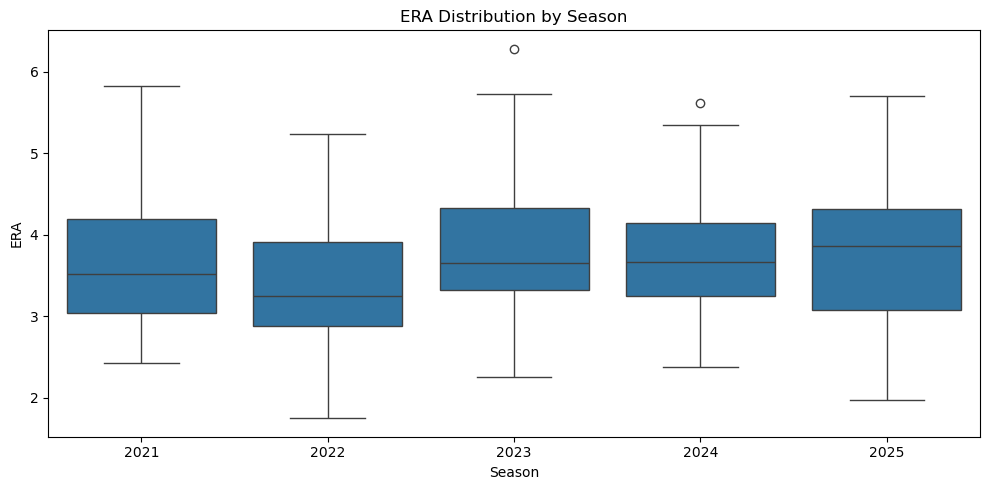

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_eda, x="season", y="ERA_num", ax=ax)
ax.set_title("ERA Distribution by Season")
ax.set_xlabel("Season")
ax.set_ylabel("ERA")
plt.tight_layout()
plt.show()


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


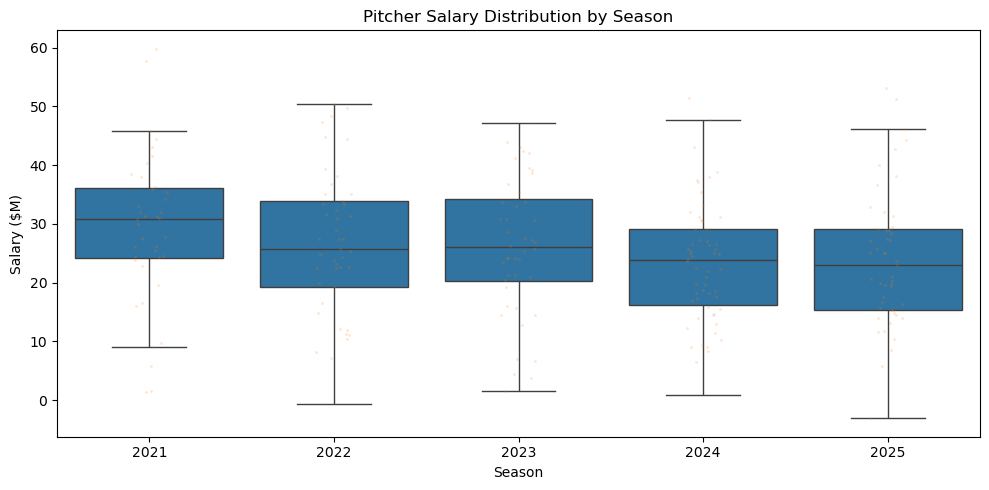

In [26]:
df_sal = df_eda.dropna(subset=["salary_M"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_sal, x="season", y="salary_M", ax=ax, showfliers=False)
sns.stripplot(data=df_sal, x="season", y="salary_M", alpha=0.2, size=2, ax=ax)
ax.set_title("Pitcher Salary Distribution by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Salary ($M)")
plt.tight_layout()
plt.show()


In [27]:
# Use apply to create IP bucket labels; cast IP to numeric first as the API returns it as a string
df_eda["IP"] = pd.to_numeric(df_eda["IP"], errors="coerce")

df_eda["IP_bucket"] = df_eda["IP"].apply(
    lambda x: "Starter (100+ IP)" if pd.notna(x) and x >= 100
         else ("Mid (50-99 IP)"   if pd.notna(x) and x >= 50
         else "Reliever (<50 IP)")
)

ip_group = df_eda.groupby("IP_bucket")[["ERA_num", "SO", "BB", "salary_M"]].agg(["mean","median"]).round(2)
print("Stats by IP bucket (Aggregate Table 3):")
print(ip_group)


Stats by IP bucket (Aggregate Table 3):
                  ERA_num             SO           BB        salary_M       
                     mean median    mean median  mean median     mean median
IP_bucket                                                                   
Starter (100+ IP)    3.67    3.6  176.05  175.0  51.1   50.0    25.58   25.3


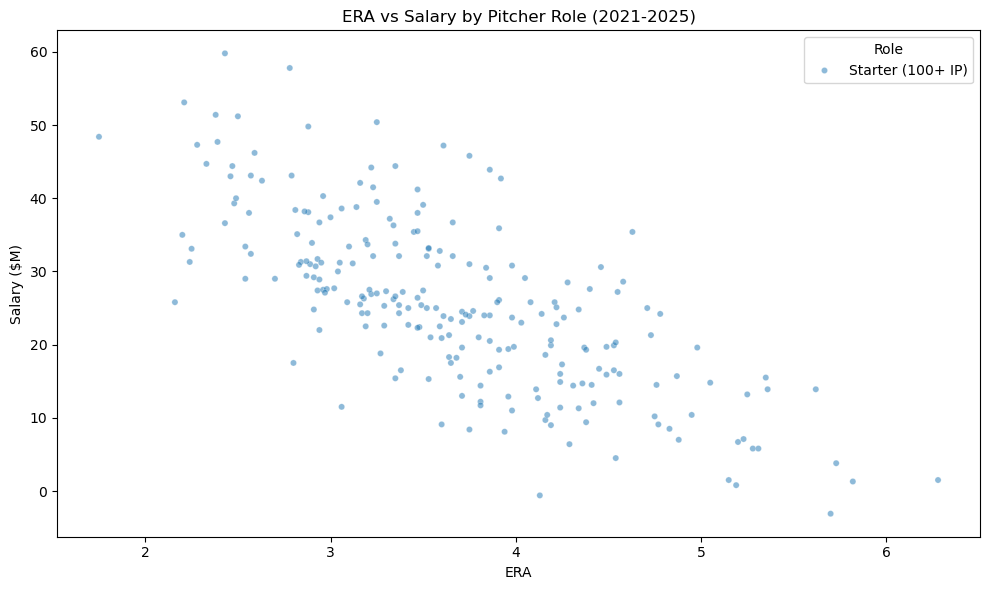

In [28]:
df_sal = df_eda.dropna(subset=["salary_M"])
df_scatter = df_sal.dropna(subset=["IP_bucket"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_scatter, x="ERA_num", y="salary_M", hue="IP_bucket", alpha=0.5, s=20, ax=ax)
ax.set_title("ERA vs Salary by Pitcher Role (2021-2025)")
ax.set_xlabel("ERA")
ax.set_ylabel("Salary ($M)")
ax.legend(title="Role")
plt.tight_layout()
plt.show()


In [29]:
# SQL SUBQUERY: Pitchers earning above their season's average salary
# A subquery computes the average salary for each season
# the outer query filters to pitchers earning more than that threshold

above_avg = pd.read_sql("""
    SELECT
        name, season, team,
        ROUND(CAST(ERA AS FLOAT), 2) AS ERA,
        IP,
        ROUND(salary / 1000000.0, 2) AS salary_M
    FROM pitcher_stats_with_salary ps
    WHERE salary > (
        SELECT AVG(salary)
        FROM pitcher_stats_with_salary sub
        WHERE sub.season = ps.season
          AND sub.salary IS NOT NULL
    )
    ORDER BY season, salary DESC
""", conn)

print(f"Pitchers earning above season average: {len(above_avg)}")
above_avg.head(15)

Pitchers earning above season average: 118


,name,season,team,ERA,IP,salary_M
0,Corbin Burnes,2021,Milwaukee Brewers,2.43,167.0,59.8
1,Zack Wheeler,2021,Philadelphia Phillies,2.78,213.1,57.8
2,Nathan Eovaldi,2021,Boston Red Sox,3.75,182.1,45.8
3,Walker Buehler,2021,Los Angeles Dodgers,2.47,207.2,44.4
4,Max Scherzer,2021,Los Angeles Dodgers,2.46,179.1,43.0
5,Gerrit Cole,2021,New York Yankees,3.23,181.1,41.5
6,Julio Urías,2021,Los Angeles Dodgers,2.96,185.2,40.3
7,Kevin Gausman,2021,San Francisco Giants,2.81,192.0,38.4
8,Brandon Woodruff,2021,Milwaukee Brewers,2.56,179.1,38.0
9,Charlie Morton,2021,Atlanta Braves,3.34,185.2,36.3


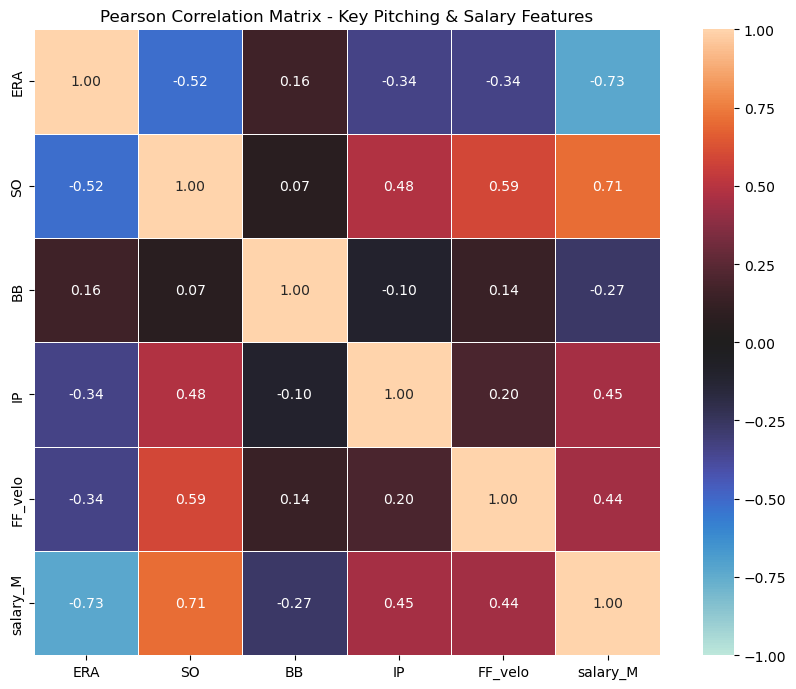

In [30]:
corr_cols = ["ERA_num", "SO", "BB", "IP", "FF_velo", "age", "salary_M"]
df_corr = df_eda[corr_cols].rename(columns={"ERA_num": "ERA"})
corr_matrix = df_corr.corr(method="pearson", numeric_only=True).round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", center=0, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Pearson Correlation Matrix - Key Pitching & Salary Features")
plt.tight_layout()
plt.show()


In [31]:
# map() used to categorize salary tier
def salary_tier(s):
    if pd.isna(s): return "Unknown"
    if s >= 20: return "Top tier ($20M+)"
    if s >= 5:  return "Mid tier ($5-20M)"
    return "Budget (<$5M)"

df_eda["salary_tier"] = df_eda["salary_M"].map(salary_tier)

tier_stats = (df_eda.dropna(subset=["salary_M"])
              .groupby(["season", "salary_tier"])["ERA_num"]
              .agg(["mean","count"]).round(2)
              .rename(columns={"mean":"avg_ERA","count":"n_pitchers"}))
print("ERA by salary tier per season:")
print(tier_stats)

ERA by salary tier per season:
                          avg_ERA  n_pitchers
season salary_tier                           
2021   Budget (<$5M)         5.48           2
       Mid tier ($5-20M)     4.56           6
       Top tier ($20M+)      3.33          31
2022   Budget (<$5M)         4.13           1
       Mid tier ($5-20M)     4.33          12
       Top tier ($20M+)      2.94          32
2023   Budget (<$5M)         5.52           3
       Mid tier ($5-20M)     4.37           8
       Top tier ($20M+)      3.55          33
2024   Budget (<$5M)         5.19           1
       Mid tier ($5-20M)     4.14          23
       Top tier ($20M+)      3.38          34
2025   Budget (<$5M)         5.70           1
       Mid tier ($5-20M)     4.29          20
       Top tier ($20M+)      3.38          28


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


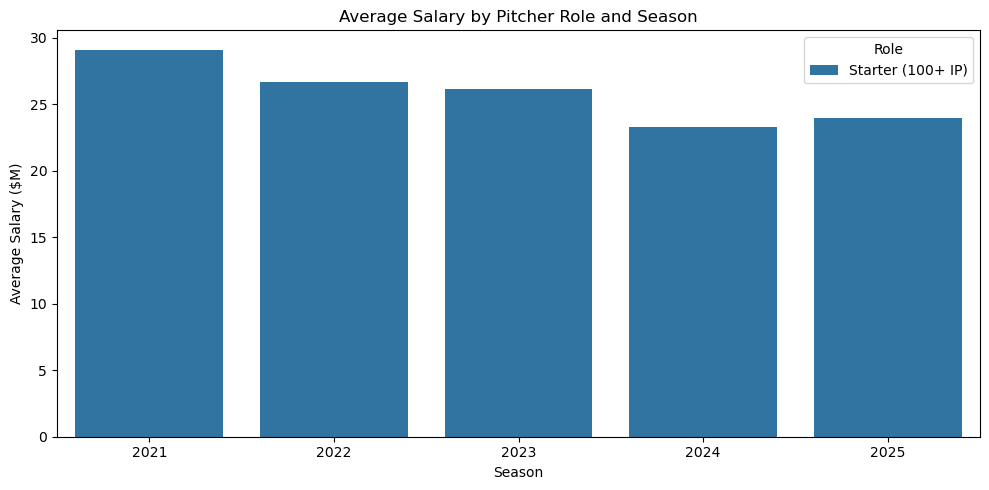

In [32]:
avg_sal = df_eda.dropna(subset=["salary_M"]).groupby(["season", "IP_bucket"])["salary_M"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=avg_sal, x="season", y="salary_M", hue="IP_bucket", ax=ax)
ax.set_title("Average Salary by Pitcher Role and Season")
ax.set_xlabel("Season")
ax.set_ylabel("Average Salary ($M)")
ax.legend(title="Role")
plt.tight_layout()
plt.show()


### Additional SQL-Driven EDA

The following queries use SQL window functions, self-joins, and grouped aggregations to explore salary efficiency and year-over-year trends directly in the database.

In [33]:
# SQL WINDOW FUNCTION: Salary compared to season and team averages
# Uses two AVG() window functions — one broken out by season, one by team
# This lets GMs benchmark a pitcher's cost against the league-wide market

salary_benchmarks = pd.read_sql("""
    SELECT
        name, season, team,
        ROUND(salary / 1000000.0, 2) AS salary_M,
        ROUND(AVG(salary / 1000000.0) OVER (PARTITION BY season), 2) AS avg_salary_season,
        ROUND(salary / 1000000.0 -
              AVG(salary / 1000000.0) OVER (PARTITION BY season), 2) AS vs_season_avg,
        ROUND(AVG(salary / 1000000.0) OVER (PARTITION BY team), 2) AS avg_salary_team,
        ROUND(salary / 1000000.0 -
              AVG(salary / 1000000.0) OVER (PARTITION BY team), 2) AS vs_team_avg
    FROM pitcher_stats_with_salary
    WHERE salary IS NOT NULL
    ORDER BY season, salary DESC
""", conn)

print("Salary vs season and team averages (sample):")
salary_benchmarks.head(15)

Salary vs season and team averages (sample):


,name,season,team,salary_M,avg_salary_season,vs_season_avg,avg_salary_team,vs_team_avg
0,Corbin Burnes,2021,Milwaukee Brewers,59.8,29.1,30.7,29.91,29.89
1,Zack Wheeler,2021,Philadelphia Phillies,57.8,29.1,28.7,36.86,20.94
2,Nathan Eovaldi,2021,Boston Red Sox,45.8,29.1,16.7,25.89,19.91
3,Walker Buehler,2021,Los Angeles Dodgers,44.4,29.1,15.3,32.04,12.36
4,Max Scherzer,2021,Los Angeles Dodgers,43.0,29.1,13.9,32.04,10.96
5,Gerrit Cole,2021,New York Yankees,41.5,29.1,12.4,29.01,12.49
6,Julio Urías,2021,Los Angeles Dodgers,40.3,29.1,11.2,32.04,8.26
7,Kevin Gausman,2021,San Francisco Giants,38.4,29.1,9.3,35.39,3.01
8,Brandon Woodruff,2021,Milwaukee Brewers,38.0,29.1,8.9,29.91,8.09
9,Charlie Morton,2021,Atlanta Braves,36.3,29.1,7.2,27.85,8.45


In [34]:
# SQL SELF-JOIN: Year-over-year salary and ERA changes per pitcher
# Joins pitcher_stats_with_salary to itself where the current season

yoy_changes = pd.read_sql("""
    SELECT
        curr.name,
        prev.season AS prev_season,
        curr.season AS curr_season,
        ROUND(CAST(prev.ERA AS FLOAT), 2) AS prev_ERA,
        ROUND(CAST(curr.ERA AS FLOAT), 2) AS curr_ERA,
        ROUND(prev.salary / 1000000.0, 2) AS prev_salary_M,
        ROUND(curr.salary / 1000000.0, 2) AS curr_salary_M,
        ROUND((curr.salary - prev.salary) / 1000000.0, 2) AS salary_change_M
    FROM pitcher_stats_with_salary curr
    INNER JOIN pitcher_stats_with_salary prev
        ON  curr.player_id = prev.player_id
        AND curr.season    = prev.season + 1
    WHERE curr.salary IS NOT NULL
      AND prev.salary IS NOT NULL
    ORDER BY ABS(curr.salary - prev.salary) DESC
    LIMIT 20
""", conn)

print("Biggest year-over-year salary changes:")
yoy_changes

Biggest year-over-year salary changes:


,name,prev_season,curr_season,prev_ERA,curr_ERA,prev_salary_M,curr_salary_M,salary_change_M
0,Charlie Morton,2021,2022,3.34,4.34,36.3,11.3,-25.0
1,José Berríos,2021,2022,3.52,5.23,32.1,7.1,-25.0
2,Corbin Burnes,2021,2022,2.43,2.94,59.8,36.7,-23.1
3,Sandy Alcantara,2022,2023,2.28,4.14,47.3,24.2,-23.1
4,Justin Verlander,2022,2023,1.75,3.22,48.4,26.9,-21.5
5,Aaron Nola,2022,2023,3.25,4.46,50.4,30.6,-19.8
6,Robbie Ray,2021,2022,2.84,3.71,31.3,13.0,-18.3
7,Kevin Gausman,2023,2024,3.16,3.83,42.1,24.0,-18.1
8,Jake Irvin,2024,2025,4.41,5.70,14.5,-3.1,-17.6
9,Germán Márquez,2021,2022,4.40,4.95,27.6,10.4,-17.2


In [35]:
# SQL GROUP BY: Fastball velocity tier and its effect on salary and ERA
# Buckets pitchers by FF_velo using a CASE expression, then aggregates.
# Shows whether the salary market explicitly rewards higher velocity,
# and whether that premium is justified by better performance.

velo_tiers = pd.read_sql("""
    SELECT
        CASE
            WHEN FF_velo >= 96 THEN '96+ mph (Elite)'
            WHEN FF_velo >= 93 THEN '93-95 mph (Above Avg)'
            WHEN FF_velo >= 90 THEN '90-92 mph (Average)'
            ELSE                    'Below 90 mph'
        END AS velo_tier,
        COUNT(*)                                     AS n_pitchers,
        ROUND(AVG(CAST(ERA AS FLOAT)), 2)            AS avg_ERA,
        ROUND(AVG(SO * 1.0 / NULLIF(BB, 0)), 2)     AS avg_K_BB,
        ROUND(AVG(salary) / 1000000.0, 2)             AS avg_salary_M
    FROM pitcher_stats_with_salary
    WHERE FF_velo IS NOT NULL AND salary IS NOT NULL AND ERA IS NOT NULL
    GROUP BY velo_tier
    ORDER BY avg_salary_M DESC
""", conn)

print("Performance and salary by fastball velocity tier:")
velo_tiers

Performance and salary by fastball velocity tier:


,velo_tier,n_pitchers,avg_ERA,avg_K_BB,avg_salary_M
0,96+ mph (Elite),41,3.33,4.34,33.89
1,93-95 mph (Above Avg),114,3.60,3.64,25.06
2,90-92 mph (Average),65,3.94,3.51,22.31
3,Below 90 mph,11,4.16,3.06,15.79


## 5. Feature Engineering

Before modeling, we engineer additional features and perform outlier handling and standardization:

- **GB_pct / FB_pct** — already computed during data collection (ground ball / fly ball rate)
- **K_BB_ratio** — strikeout-to-walk ratio, a key efficiency metric
- **IP_bucket** — role classification based on innings pitched
- **Outlier handling** — capping ERA at the 99th percentile rather than arbitrary cutoff
- **StandardScaler** — normalizing features before regression to put coefficients on comparable scales

In [36]:
df_all = pd.read_sql("SELECT * FROM pitcher_stats_with_salary", conn)
print("Columns:", sorted(df_all.columns.tolist()))
print(f"\nRows: {len(df_all):,}")
check_cols = ["ERA", "SO", "BB", "IP", "FF_velo", "age", "GB_pct", "salary"]
present = [c for c in check_cols if c in df_all.columns]
print("\nNon-null counts:")
print(df_all[present].notna().sum().to_string())


Columns: ['BB', 'CH_pct', 'CU_pct', 'ER', 'ERA', 'EV', 'FB_pct', 'FC_pct', 'FF_ivb', 'FF_pct', 'FF_velo', 'FS_pct', 'G', 'GB_pct', 'GS', 'H', 'IP', 'R', 'SI_pct', 'SL_pct', 'SO', 'ST_pct', 'SV_pct', 'age', 'name', 'player_id', 'salary', 'season', 'team', 'xERA', 'xwOBA']

Rows: 238

Non-null counts:
ERA        238
SO         238
BB         238
IP         238
FF_velo    234
age          0
GB_pct     238
salary     235


In [37]:
from sklearn.preprocessing import StandardScaler

df_cols = pd.read_sql("SELECT * FROM pitcher_stats_with_salary LIMIT 0", conn).columns.tolist()

def col_has_data(col, n=100):
    if col not in df_cols:
        return False
    count = pd.read_sql(
        "SELECT COUNT(" + col + ") AS n FROM pitcher_stats_with_salary WHERE " + col + " IS NOT NULL",
        conn
    ).iloc[0]["n"]
    return count > n

has_age = col_has_data("age")
has_ff_velo = col_has_data("FF_velo")
has_gb_pct = col_has_data("GB_pct")

select_cols = ["name", "season", "team", "IP", "ERA", "SO", "BB"]
if has_age: select_cols.append("age")
if has_ff_velo: select_cols.append("FF_velo")
if has_gb_pct: select_cols.append("GB_pct")
select_cols.append("salary")

where = ["ERA IS NOT NULL", "SO IS NOT NULL", "BB IS NOT NULL", "CAST(ERA AS FLOAT) < 20"]
if has_age: where.append("age IS NOT NULL")
if has_ff_velo: where.append("FF_velo IS NOT NULL")

query = "SELECT " + ", ".join(select_cols) + " FROM pitcher_stats_with_salary WHERE " + " AND ".join(where)

df_model_raw = pd.read_sql(query, conn)
df_model_raw = df_model_raw.apply(
    lambda c: pd.to_numeric(c, errors="coerce") if c.name not in ["name", "team"] else c
)
df_model_raw = df_model_raw.dropna(subset=["ERA", "SO", "BB"])

df_model_raw["K_BB_ratio"] = df_model_raw.apply(
    lambda row: row["SO"] / row["BB"] if row["BB"] > 0 else np.nan, axis=1
)

era_cap = df_model_raw["ERA"].quantile(0.99)
df_model_raw = df_model_raw[df_model_raw["ERA"] <= era_cap]

df_with_sal = df_model_raw.dropna(subset=["salary"]).copy()
sal_cap = df_with_sal["salary"].quantile(0.99)
df_with_sal = df_with_sal[df_with_sal["salary"] <= sal_cap]
df_with_sal["salary_M"] = df_with_sal["salary"] / 1_000_000

print(f"{len(df_model_raw)} rows for ERA model, {len(df_with_sal)} for salary model")


231 rows for ERA model, 225 for salary model


In [38]:
ERA_FEATURES = ["SO", "BB"]
SALARY_FEATURES = ["ERA", "SO", "BB"]

for feat in ["age", "FF_velo", "K_BB_ratio", "GB_pct"]:
    if feat in df_model_raw.columns and df_model_raw[feat].notna().sum() > 50:
        ERA_FEATURES.append(feat)
    if feat in df_with_sal.columns and df_with_sal[feat].notna().sum() > 50:
        SALARY_FEATURES.append(feat)

print("ERA features:", ERA_FEATURES)
print("Salary features:", SALARY_FEATURES)

df_era_clean = df_model_raw.dropna(subset=ERA_FEATURES + ["ERA"])
df_sal_clean = df_with_sal.dropna(subset=SALARY_FEATURES + ["salary_M"])

assert len(df_era_clean) > 0
assert len(df_sal_clean) > 0

scaler_era = StandardScaler()
X1 = scaler_era.fit_transform(df_era_clean[ERA_FEATURES].values)
y1 = df_era_clean["ERA"].values

scaler_sal = StandardScaler()
X2 = scaler_sal.fit_transform(df_sal_clean[SALARY_FEATURES].values)
y2 = df_sal_clean["salary_M"].values


ERA features: ['SO', 'BB', 'FF_velo', 'K_BB_ratio', 'GB_pct']
Salary features: ['ERA', 'SO', 'BB', 'FF_velo', 'K_BB_ratio', 'GB_pct']


## 6. Regression Models

### Model 1: Predicting ERA from pitching metrics
Features: SO, BB, FF_velo (fastball velocity), age, K/BB ratio  
Target: ERA

### Model 2: Predicting Salary from performance metrics
Features: ERA, SO, BB, FF_velo, age, K/BB ratio, GB%  
Target: Salary ($M)

Both models use **StandardScaler**-normalized inputs so coefficients are directly comparable.

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

reg1 = LinearRegression().fit(X1, y1)
y1_pred = reg1.predict(X1)

print("Model 1: ERA ~", " + ".join(ERA_FEATURES))
print(f"  R2:        {r2_score(y1, y1_pred):.4f}")
print(f"  RMSE:      {np.sqrt(mean_squared_error(y1, y1_pred)):.4f}")
print(f"  Intercept: {reg1.intercept_:.4f}")
for feat, coef in zip(ERA_FEATURES, reg1.coef_):
    print(f"  {feat}: {coef:.4f}")


Model 1: ERA ~ SO + BB + FF_velo + K_BB_ratio + GB_pct
  R2:        0.3270
  RMSE:      0.6432
  Intercept: 3.6520
  SO: -0.4109
  BB: 0.1708
  FF_velo: -0.0311
  K_BB_ratio: 0.0076
  GB_pct: -0.0963


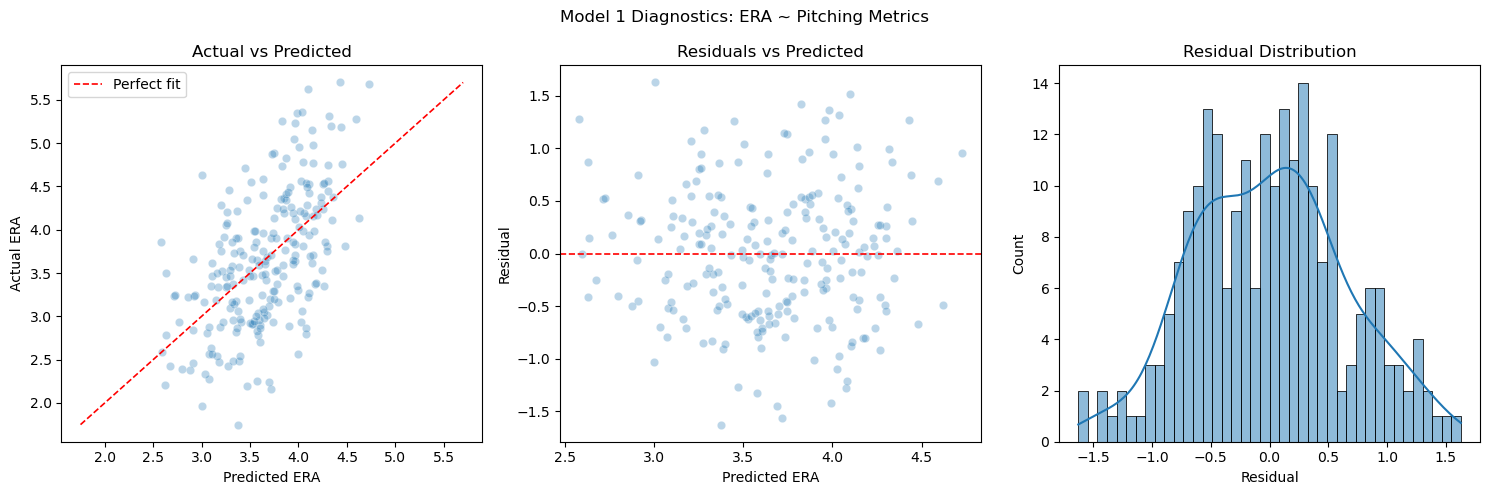

In [40]:
plot_df1 = df_era_clean[ERA_FEATURES + ["ERA"]].copy()
plot_df1["ERA_pred"] = y1_pred
plot_df1["residual"] = y1 - y1_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model 1 Diagnostics: ERA ~ Pitching Metrics")

ax = axes[0]
sns.scatterplot(data=plot_df1, x="ERA_pred", y="ERA", alpha=0.3, ax=ax)
lims = [plot_df1[["ERA", "ERA_pred"]].min().min(), plot_df1[["ERA", "ERA_pred"]].max().max()]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfect fit")
ax.set_xlabel("Predicted ERA")
ax.set_ylabel("Actual ERA")
ax.set_title("Actual vs Predicted")
ax.legend()

ax = axes[1]
sns.scatterplot(data=plot_df1, x="ERA_pred", y="residual", alpha=0.3, ax=ax)
ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("Predicted ERA")
ax.set_ylabel("Residual")
ax.set_title("Residuals vs Predicted")

ax = axes[2]
sns.histplot(plot_df1["residual"], bins=40, kde=True, ax=ax)
ax.set_xlabel("Residual")
ax.set_title("Residual Distribution")

plt.tight_layout()
plt.show()


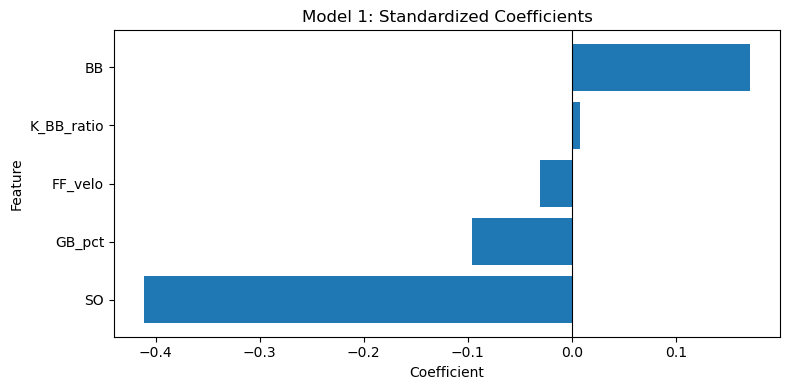

In [41]:
coef_df1 = pd.DataFrame({"feature": ERA_FEATURES, "coefficient": reg1.coef_}).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(coef_df1["feature"], coef_df1["coefficient"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Model 1: Standardized Coefficients")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


In [42]:
reg2 = LinearRegression().fit(X2, y2)
y2_pred = reg2.predict(X2)

print("Model 2: Salary ~", " + ".join(SALARY_FEATURES))
print(f"  R2:        {r2_score(y2, y2_pred):.4f}")
print(f"  RMSE:      ${np.sqrt(mean_squared_error(y2, y2_pred)):.2f}M")
print(f"  Intercept: {reg2.intercept_:.4f}")
for feat, coef in zip(SALARY_FEATURES, reg2.coef_):
    print(f"  {feat}: {coef:.4f}")


Model 2: Salary ~ ERA + SO + BB + FF_velo + K_BB_ratio + GB_pct
  R2:        0.7529
  RMSE:      $5.48M
  Intercept: 25.3013
  ERA: -4.2265
  SO: 5.3556
  BB: -1.9974
  FF_velo: 0.1513
  K_BB_ratio: 1.2397
  GB_pct: 1.9214


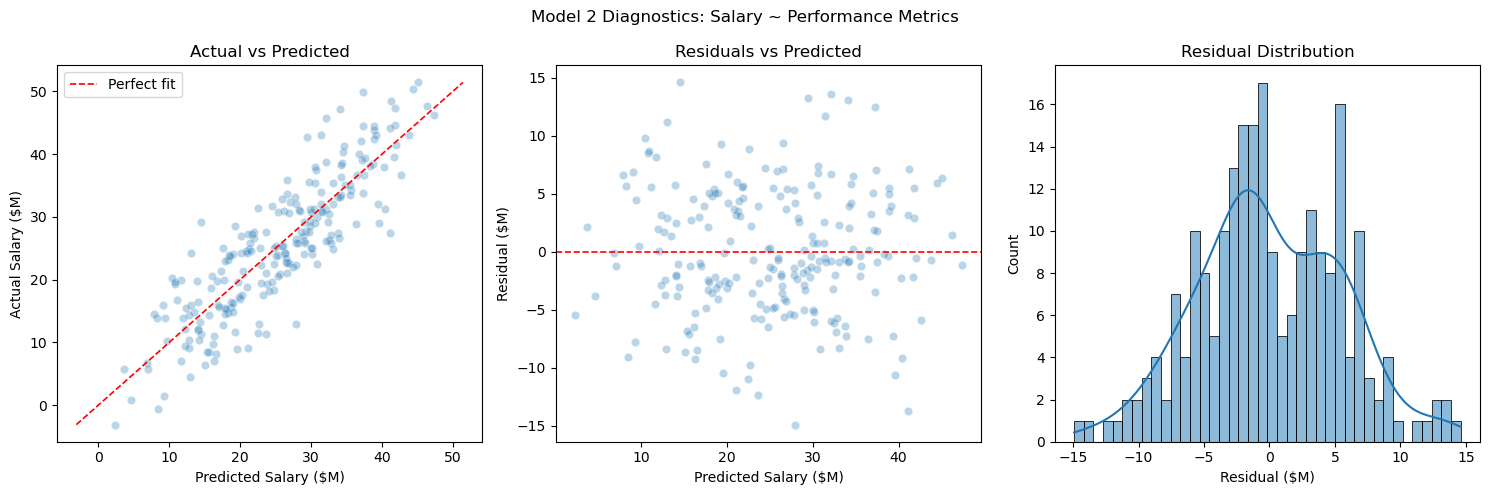

In [43]:
plot_df2 = df_sal_clean[SALARY_FEATURES + ["salary_M"]].copy()
plot_df2["sal_pred"] = y2_pred
plot_df2["residual"] = y2 - y2_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model 2 Diagnostics: Salary ~ Performance Metrics")

ax = axes[0]
sns.scatterplot(data=plot_df2, x="sal_pred", y="salary_M", alpha=0.3, ax=ax)
lims = [plot_df2[["salary_M", "sal_pred"]].min().min(), plot_df2[["salary_M", "sal_pred"]].max().max()]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfect fit")
ax.set_xlabel("Predicted Salary ($M)")
ax.set_ylabel("Actual Salary ($M)")
ax.set_title("Actual vs Predicted")
ax.legend()

ax = axes[1]
sns.scatterplot(data=plot_df2, x="sal_pred", y="residual", alpha=0.3, ax=ax)
ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("Predicted Salary ($M)")
ax.set_ylabel("Residual ($M)")
ax.set_title("Residuals vs Predicted")

ax = axes[2]
sns.histplot(plot_df2["residual"], bins=40, kde=True, ax=ax)
ax.set_xlabel("Residual ($M)")
ax.set_title("Residual Distribution")

plt.tight_layout()
plt.show()


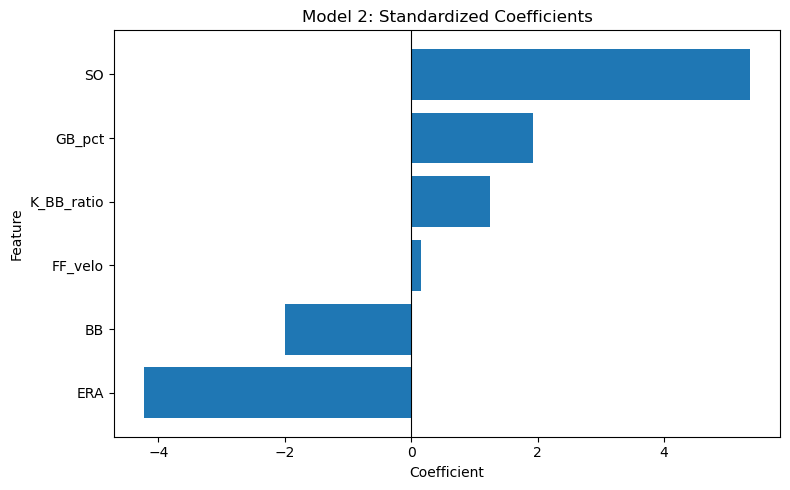

In [44]:
coef_df2 = pd.DataFrame({"feature": SALARY_FEATURES, "coefficient": reg2.coef_}).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_df2["feature"], coef_df2["coefficient"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Model 2: Standardized Coefficients")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


## 7. Surplus Value Analysis

Using Model 2, we predict what each pitcher *should* earn based on their statistics, then compute the gap between predicted and actual salary.

- **Positive surplus** → pitcher is underpaid (good value for a team)
- **Negative surplus** → pitcher is overpaid

In [45]:
df_surplus = df_sal_clean.copy()
X_scaled = scaler_sal.transform(df_surplus[SALARY_FEATURES].values)
df_surplus["expected_salary_M"] = reg2.predict(X_scaled)
df_surplus["surplus_M"] = df_surplus["expected_salary_M"] - df_surplus["salary_M"]


In [46]:
display_cols = ["name", "season", "team", "IP", "ERA", "SO", "salary_M", "expected_salary_M", "surplus_M"]
print("Top 20 most underpaid (2021-2025)")
print(df_surplus.sort_values("surplus_M", ascending=False).head(20)[display_cols].round(2).to_string(index=False))


Top 20 most underpaid (2021-2025)
            name  season                team    IP  ERA  SO  salary_M  expected_salary_M  surplus_M
      Robbie Ray    2022    Seattle Mariners 189.0 3.71 212      13.0              27.92      14.92
     Gerrit Cole    2022    New York Yankees 200.2 3.50 257      27.4              41.12      13.72
  Charlie Morton    2022      Atlanta Braves 172.0 4.34 205      11.3              23.64      12.34
    José Berríos    2024   Toronto Blue Jays 192.1 3.60 153       9.1              21.05      11.95
  Gavin Williams    2025 Cleveland Guardians 167.2 3.06 173      11.5              22.49      10.99
Shane McClanahan    2022      Tampa Bay Rays 166.1 2.54 194      29.0              39.62      10.62
  Charlie Morton    2024      Atlanta Braves 165.1 4.19 167       9.0              19.49      10.49
    Carlos Rodón    2024    New York Yankees 175.0 3.96 195      12.9              22.67       9.77
   Lucas Giolito    2023 Cleveland Guardians 184.1 4.88 204       

In [47]:
print("Top 20 most overpaid (2021-2025)")
print(df_surplus.sort_values("surplus_M").head(20)[display_cols].round(2).to_string(index=False))


Top 20 most overpaid (2021-2025)
             name  season                  team    IP  ERA  SO  salary_M  expected_salary_M  surplus_M
    Michael Wacha    2025    Kansas City Royals 172.2 3.86 126      29.1              14.50     -14.60
   Nathan Eovaldi    2021        Boston Red Sox 182.1 3.75 195      45.8              32.15     -13.65
    Jesús Luzardo    2025 Philadelphia Phillies 183.2 3.92 216      42.7              29.46     -13.24
     Zack Wheeler    2023 Philadelphia Phillies 192.0 3.61 212      47.2              34.13     -13.07
     Carlos Rodón    2022  San Francisco Giants 178.0 2.88 237      49.8              37.29     -12.51
       Sonny Gray    2023       Minnesota Twins 184.0 2.79 183      43.1              31.38     -11.72
    Miles Mikolas    2023   St. Louis Cardinals 201.1 4.78 137      24.2              13.04     -11.16
    Luis Severino    2025             Athletics 162.2 4.54 124      20.3              10.45      -9.85
      Dylan Cease    2021     Chicago Wh

### Surplus Value Cross-Referenced with Statcast Metrics

Join the surplus value predictions back to the raw Statcast data to see whether advanced metrics (xERA, xwOBA, exit velocity) corroborate the model's over/underpaid findings.

In [48]:
# SQL JOIN: Surplus value joined with Statcast advanced metrics
# Joins pitcher_surplus_value back to pitcher_stats to pull xERA, xwOBA, and EV
# This lets us validate whether Statcast metrics agree with the model's assessment.

surplus_statcast = pd.read_sql("""
    SELECT
        sv.name, sv.season, sv.team,
        ROUND(sv.ERA, 2)                AS ERA,
        ROUND(ps.xERA, 2)              AS xERA,
        ROUND(ps.xwOBA, 3)             AS xwOBA,
        ROUND(ps.EV, 1)                AS exit_velo,
        ROUND(sv.salary_M, 2)          AS actual_salary_M,
        ROUND(sv.expected_salary_M, 2) AS model_salary_M,
        ROUND(sv.surplus_M, 2)         AS surplus_M
    FROM pitcher_surplus_value sv
    INNER JOIN pitcher_stats ps
        ON  sv.name   = ps.name
        AND sv.season = ps.season
    ORDER BY sv.surplus_M DESC
    LIMIT 20
""", conn)

print("Most underpaid pitchers — with Statcast context:")
surplus_statcast

Most underpaid pitchers — with Statcast context:


,name,season,team,ERA,xERA,xwOBA,exit_velo,actual_salary_M,model_salary_M,surplus_M
0,Robbie Ray,2022,Seattle Mariners,3.71,3.62,0.299,89.7,13.0,27.92,14.92
1,Gerrit Cole,2022,New York Yankees,3.50,3.39,0.290,89.4,27.4,41.12,13.72
2,Charlie Morton,2022,Atlanta Braves,4.34,4.14,0.318,89.3,11.3,23.64,12.34
3,José Berríos,2024,Toronto Blue Jays,3.60,4.68,0.336,89.6,9.1,21.05,11.95
4,Gavin Williams,2025,Cleveland Guardians,3.06,4.30,0.321,90.4,11.5,22.49,10.99
5,Shane McClanahan,2022,Tampa Bay Rays,2.54,2.75,0.262,87.6,29.0,39.62,10.62
6,Charlie Morton,2024,Atlanta Braves,4.19,4.52,0.331,88.7,9.0,19.49,10.49
7,Carlos Rodón,2024,New York Yankees,3.96,4.08,0.316,90.4,12.9,22.67,9.77
8,Lucas Giolito,2023,Cleveland Guardians,4.88,4.61,0.329,89.2,7.0,16.26,9.26
9,Robbie Ray,2021,Toronto Blue Jays,2.84,3.60,0.293,90.4,31.3,40.44,9.14


### Worst Value Contracts: High ERA + High Salary

Identify pitchers with above-average ERA (poor performance) AND above-average salary — the contracts a front office would most want to move.

In [49]:
# SQL SUBQUERY: Finds pitchers with above-average ERA AND above-average salary
# Uses two subqueries one for the ERA threshold and salary threshold
# The outer query filters to pitchers exceeding both.

worst_value = pd.read_sql("""
    SELECT
        ps.name, ps.season, ps.team,
        ROUND(CAST(ps.ERA AS FLOAT), 2) AS ERA,
        ROUND(ps.IP, 1) AS IP,
        ROUND(ps.salary / 1000000.0, 2) AS salary_M
    FROM pitcher_stats_with_salary ps
    WHERE CAST(ps.ERA AS FLOAT) > (
            SELECT AVG(CAST(ERA AS FLOAT))
            FROM pitcher_stats_with_salary
            WHERE season = ps.season
              AND ERA IS NOT NULL AND CAST(ERA AS FLOAT) < 20
          )
      AND ps.salary > (
            SELECT AVG(salary)
            FROM pitcher_stats_with_salary
            WHERE season = ps.season AND salary IS NOT NULL
          )
      AND ps.ERA IS NOT NULL
    ORDER BY ps.salary DESC
""", conn)

print(f"Worst value contracts (above-avg ERA AND above-avg salary): {len(worst_value)}")
worst_value

Worst value contracts (above-avg ERA AND above-avg salary): 23


,name,season,team,ERA,IP,salary_M
0,Nathan Eovaldi,2021,Boston Red Sox,3.75,182.1,45.8
1,Kevin Gausman,2022,Toronto Blue Jays,3.35,174.2,44.4
2,Spencer Strider,2023,Atlanta Braves,3.86,186.2,43.9
3,Jesús Luzardo,2025,Philadelphia Phillies,3.92,183.2,42.7
4,Dylan Cease,2021,Chicago White Sox,3.91,165.2,35.9
5,Aaron Nola,2021,Philadelphia Phillies,4.63,180.2,35.4
6,Tyler Mahle,2021,Cincinnati Reds,3.75,180.0,31.0
7,Luis Castillo,2021,Cincinnati Reds,3.98,187.2,30.8
8,Aaron Nola,2023,Philadelphia Phillies,4.46,193.2,30.6
9,Sonny Gray,2024,St. Louis Cardinals,3.84,166.1,30.5


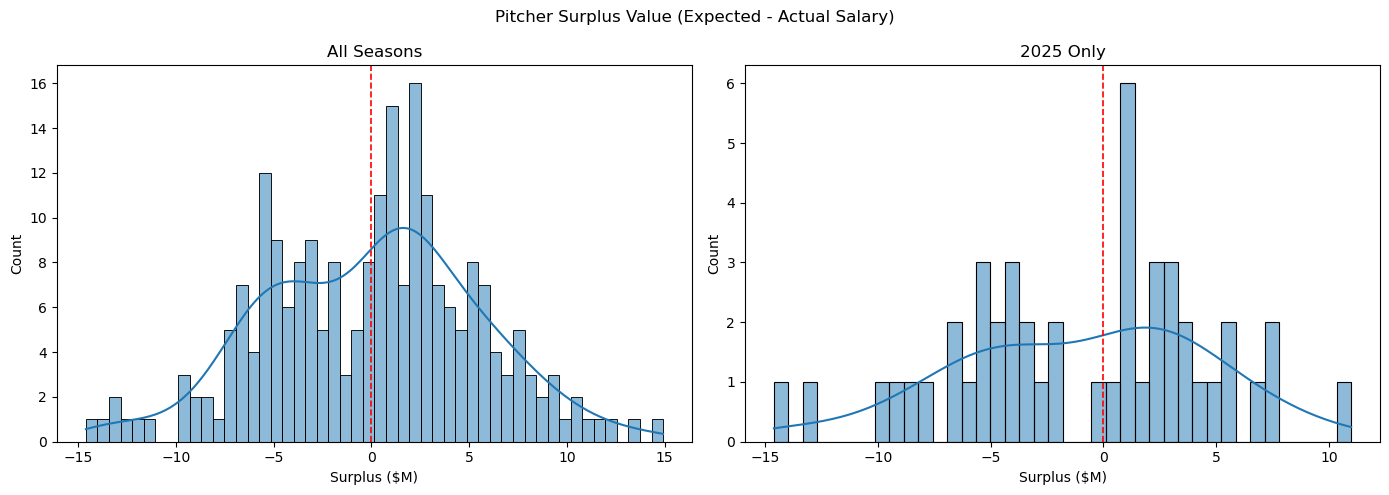

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pitcher Surplus Value (Expected - Actual Salary)")

sns.histplot(df_surplus["surplus_M"], bins=50, kde=True, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Surplus ($M)")
axes[0].set_ylabel("Count")
axes[0].set_title("All Seasons")

df_2025_s = df_surplus[df_surplus["season"] == 2025]
sns.histplot(df_2025_s["surplus_M"], bins=40, kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Surplus ($M)")
axes[1].set_title("2025 Only")

plt.tight_layout()
plt.show()


In [51]:
df_surplus.to_sql("pitcher_surplus_value", conn, if_exists="replace", index=False)
print(f"✅ Saved pitcher_surplus_value: {len(df_surplus):,} rows")

✅ Saved pitcher_surplus_value: 225 rows


In [52]:
# Top 3 value targets from 2025
print("Top 3 Value Targets (2025 Season)")
print(df_surplus[df_surplus["season"] == 2025].sort_values("surplus_M", ascending=False).head(3)[display_cols].round(2).to_string(index=False))

Top 3 Value Targets (2025 Season)
          name  season                team    IP  ERA  SO  salary_M  expected_salary_M  surplus_M
Gavin Williams    2025 Cleveland Guardians 167.2 3.06 173      11.5              22.49      10.99
  Zack Littell    2025     Cincinnati Reds 186.2 3.81 130      11.7              19.20       7.50
     Bryan Woo    2025    Seattle Mariners 186.2 2.94 198      28.9              36.39       7.49


## 8. Conclusion

### Key Findings

**Predicting ERA (R2 = 0.33):**  
Pitching metrics explain about 33% of ERA variance. While ERA is noisy — influenced by defense, sequencing, and luck — the model still surfaces meaningful relationships. Strikeouts had the strongest negative coefficient (more SO → lower ERA), followed by ground ball rate. Fastball velocity also contributed negatively, confirming that harder throwers tend to have lower ERAs.

**Predicting Salary (R2 = 0.75):**  
Performance metrics explain about 75% of salary variance, confirming that the market broadly rewards statistical production. Strikeouts had the largest positive coefficient ($5.36M per standard deviation increase), followed by GB% and K/BB ratio. ERA had a strong negative coefficient — lower ERA drives higher pay. The model is reasonably efficient but meaningful surplus gaps remain.

**Surplus Value:**  
Several pitchers consistently appeared underpaid relative to their statistical profiles (especially younger pitchers on pre-arbitration contracts). Overpaid pitchers often reflect long-term deals signed during peak performance years that have since declined. Our model identified Gavin Williams, Zack Littell, and Bryan Woo as the strongest value targets.

### Limitations
- ERA is a noisy metric; using FIP or xFIP as a target may improve Model 1
- Long-term contracts distort the salary-performance relationship; a year-0 vs. year-4+ contract analysis would be valuable

### Future Work
- Incorporate contract year (year N of M) as a feature to distinguish pre-/post-peak contract performance
- Add fielding-independent metrics (FIP, xFIP, SIERA) to improve ERA modeling
- Extend the dataset to 2015-2025 to capture more contract cycles
- Use regularized regression (Ridge/Lasso) to handle collinear pitch-type features